In [3]:
%pip install -q python-dotenv langchain-openai

/home/swjeong/langchain/langgraph/inflearn-langgraph-agent/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [4]:
from dotenv import load_dotenv

load_dotenv()

True

In [5]:
from langchain_openai import ChatOpenAI

query = "충북 최고 아웃풋 충북대학교의 자랑은 누구인가요?"

llm = ChatOpenAI(model = "gpt-4o-mini")
llm.invoke(query)

AIMessage(content='충북대학교의 자랑은 다양한 분야에서 활동하고 있는 많은 우수한 인재들입니다. 특히, 충북대학교는 연구와 교육 면에서 많은 성과를 이루어낸 교수진과 졸업생들이 있습니다. \n\n또한, 충북대학교는 과학기술, 인문사회, 예술 등 다양한 분야에서 두각을 나타내고 있으며, 특히 농업, 환경, 생명과학 분야에서의 연구 성과로 잘 알려져 있습니다. 이러한 성과들은 충북대학교의 명성을 높이고 있으며, 지역사회와 국가 발전에도 기여하고 있습니다.\n\n특정 개인을 언급하기보다는, 충북대학교에서 배출된 여러 인재들과 그들의 성과가 학교의 자랑이라고 할 수 있습니다. 각 분야에서 활발히 활동하는 졸업생들이 있으며, 이들은 충북대학교의 위상을 높이는 데 기여하고 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 194, 'prompt_tokens': 25, 'total_tokens': 219, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_7ef2449383', 'finish_reason': 'stop', 'logprobs': None}, id='run-3c869808-f99b-467f-a6b2-70322e72c3ca-0', usage_metadata={'input_tokens': 25, 'output_tokens': 194, 'total_tokens': 219, 'input_token

# State: 현재 Agent의 상태
# Node: Agent가 수행하는 작업 (Agent A, Agent B ..., retriever, generator, ...)
# Edge: 노드 간의 관계를 나타낸다. (실선은 무조건 실행, 점선은 조건에 따라 실행)
# Conditional Edge: 조건에 따라 다른 노드로 이동한다.
#LangChain은 무조건 rewrite를 해야하지만 LangGraph는 조건에 따라 다른 노드로
# 이동할 수 있으므로 필요할 때만 rewrite가 가능하다.

In [6]:
%pip install -q langgraph

/home/swjeong/langchain/langgraph/inflearn-langgraph-agent/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

class AgentState(TypedDict):
    messages: list[Annotated[AnyMessage, add_messages]] 
    #Annotated는 타입 힌트를 추가하는 함수이다.
    #AnyMessages는 SystemMessage, HumanMessage, AIMEssage를 포함하고있다.

In [8]:
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

In [9]:
def generate(state: AgentState) -> AgentState:
    messages = state['messages']
    ai_message = llm.invoke(messages)
    return {'messages': [ai_message]}

In [10]:
from langgraph.graph import START, END
graph_builder.add_node('generate', generate)
graph_builder.add_edge(START, 'generate')
graph_builder.add_edge('generate', END)

In [11]:
graph = graph_builder.compile()

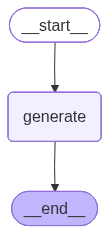

In [12]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
from langchain_core.messages import HumanMessage

initial_state = {'messages': [HumanMessage(query)]}
graph.invoke(initial_state)

{'messages': [AIMessage(content='충북대학교의 자랑은 여러 분야에서 뛰어난 성과를 거두는 교수진과 학생들입니다. 특히, 연구와 학문적 기여에서 두각을 나타내는 교수진, 다양한 국내외 대회에서 우수한 성적을 거두는 학생들, 그리고 혁신적인 프로젝트나 창업에 성공한 졸업생들이 충북대학교를 자랑스럽게 만드는 요소들입니다. 또한, 충북대학교는 지역사회와의 협력을 통해 다양한 사회적 기여를 하고 있어 그 또한 큰 자랑거리입니다. 특정 인물이나 성과를 언급하면 더 구체적인 정보를 제공할 수 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 140, 'prompt_tokens': 25, 'total_tokens': 165, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_7ef2449383', 'finish_reason': 'stop', 'logprobs': None}, id='run-64e2e32b-e89d-46a6-816b-cb6154e6877e-0', usage_metadata={'input_tokens': 25, 'output_tokens': 140, 'total_tokens': 165, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}